In [1]:
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms.v2 as T
from torch.utils.data import DataLoader

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [3]:
transform = T.Compose([T.ToImage(), T.ToDtype(torch.float32, scale=True)])

train_and_valid_data = torchvision.datasets.EMNIST(
    root="datasets", split="balanced", train=True, transform=transform, download=True)

test_data = torchvision.datasets.EMNIST(
    root="datasets", split="balanced", train=False, transform=transform)

In [4]:
len(train_and_valid_data)

112800

In [5]:
len(test_data)

18800

In [6]:
train_data, valid_data = torch.utils.data.random_split(train_and_valid_data, [107800, 5000])

In [7]:
train_loader = DataLoader(train_data, batch_size=256, num_workers=4, pin_memory=True, shuffle=True)
valid_loader = DataLoader(valid_data, batch_size=256, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_data,   batch_size=256, num_workers=4, pin_memory=True)

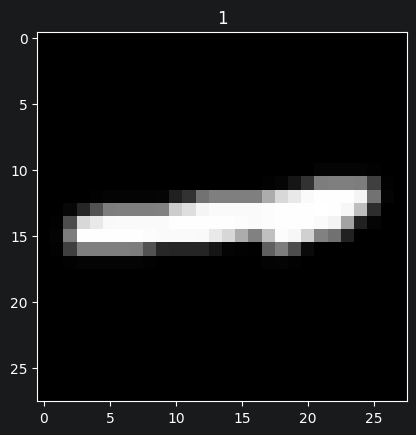

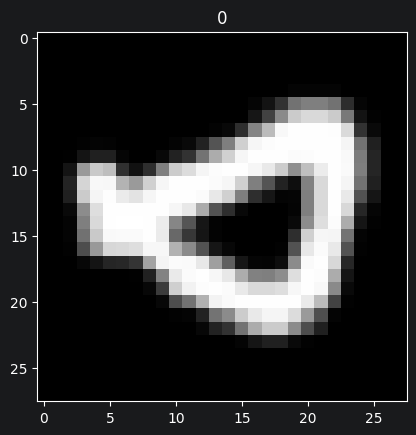

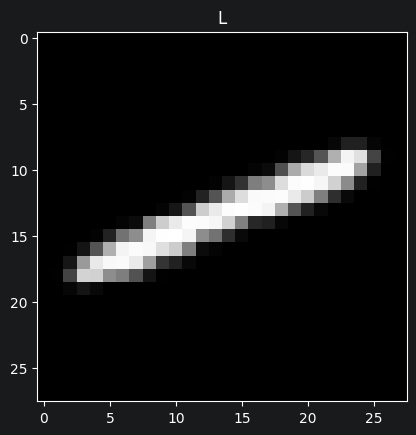

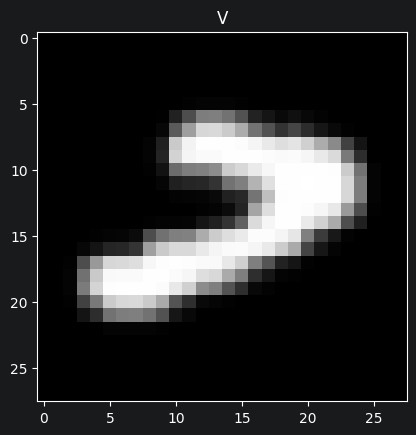

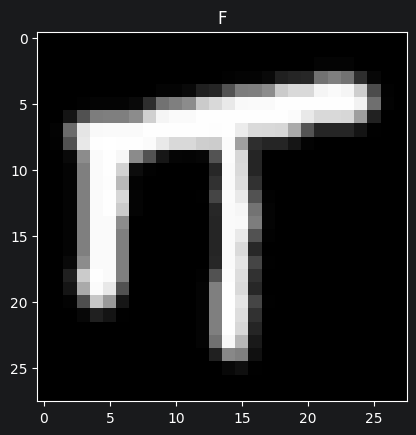

In [8]:
def plot_symbol(symbol):
    grid = torchvision.utils.make_grid(symbol[0])
    label = symbol[1]
    plt.imshow(grid.permute(1, 2, 0))
    plt.title(train_and_valid_data.classes[label])
    plt.show()

for i in range(5):
    plot_symbol(train_data[i])

In [9]:
n_classes = len(train_and_valid_data.classes)
n_classes

47

In [10]:
class WideAndDeepEMNIST(nn.Module):
    def __init__(self, layer_sizes, n_classes, n_features):
        super().__init__()
        layers = [nn.Flatten()]
        for in_size, out_size in zip(layer_sizes[:-1], layer_sizes[1:]):
            layers.append(nn.Linear(in_size, out_size))
            layers.append(nn.ReLU())
        self.layers = nn.Sequential(*layers)
        self.output_layer = nn.Linear(layer_sizes[-1] + n_features, n_classes)


    def forward(self, X):
        deep_output = self.layers(X)
        deep_and_wide = torch.concat([deep_output, X.flatten(1)], dim=1)
        return self.output_layer(deep_and_wide)

In [11]:
def evaluate(model, valid_loader, metric):
    model.eval()
    metric.reset()
    with torch.no_grad():
        for X_batch, y_batch in valid_loader:
            X_batch, y_batch = X_batch.to(device, non_blocking=True), y_batch.to(device, non_blocking=True)
            y_pred = model(X_batch)
            metric.update(y_pred, y_batch)
    model.train()
    return metric.compute().item()

In [12]:
def train(model, optimizer, criterion, train_loader, valid_loader, n_epochs, metric):
    model.train()
    for epoch in range(n_epochs):
        total_loss = 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device, non_blocking=True), y_batch.to(device, non_blocking=True)
            optimizer.zero_grad()
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            total_loss += loss.item()
            loss.backward()
            optimizer.step()

        mean_loss = total_loss / len(train_loader)
        metrics = evaluate(model, valid_loader, metric)
        print(f"Epoch: {epoch + 1}/{n_epochs}, Loss: {mean_loss:.4f}, Val Score: {metrics:.4f}")

In [13]:
import torchmetrics

model = WideAndDeepEMNIST([784, 256, 128], n_classes=47, n_features=28*28).to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss()
metric = torchmetrics.Accuracy(task="multiclass", num_classes=47).to(device)

train(model, optimizer, criterion, train_loader, valid_loader, 10, metric)

Epoch: 1/10, Loss: 3.3705, Val Score: 0.4524
Epoch: 2/10, Loss: 2.6843, Val Score: 0.5100
Epoch: 3/10, Loss: 2.2990, Val Score: 0.5374
Epoch: 4/10, Loss: 2.0672, Val Score: 0.5524
Epoch: 5/10, Loss: 1.9184, Val Score: 0.5626
Epoch: 6/10, Loss: 1.8131, Val Score: 0.5722
Epoch: 7/10, Loss: 1.7362, Val Score: 0.5792
Epoch: 8/10, Loss: 1.6788, Val Score: 0.5866
Epoch: 9/10, Loss: 1.6303, Val Score: 0.5920
Epoch: 10/10, Loss: 1.5911, Val Score: 0.5966


In [14]:
import optuna

def objective(trial):
    learning_rate = trial.suggest_float("learning_rate", 1e-5, 1e-1, log=True)
    n_layers = trial.suggest_int("n_layers", 2, 5)

    layer_sizes = [784]
    for i in range(n_layers):
        layer_sizes.append(trial.suggest_int(f"layer_{i}", 32, 512))

    model = WideAndDeepEMNIST(layer_sizes, n_classes=47, n_features=28*28).to(device)
    optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
    criterion = nn.CrossEntropyLoss()
    metric = torchmetrics.Accuracy(task="multiclass", num_classes=47).to(device)

    train(model, optimizer, criterion, train_loader, valid_loader, n_epochs=5, metric=metric)

    return evaluate(model, valid_loader, metric)

In [15]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=15)

[I 2026-05-30 23:14:10,334] A new study created in memory with name: no-name-ae3acd82-4aab-48c1-8768-576d57531b0a


Epoch: 1/5, Loss: 3.8628, Val Score: 0.0198
Epoch: 2/5, Loss: 3.8598, Val Score: 0.0208
Epoch: 3/5, Loss: 3.8569, Val Score: 0.0220
Epoch: 4/5, Loss: 3.8540, Val Score: 0.0238
Epoch: 5/5, Loss: 3.8512, Val Score: 0.0246


[I 2026-05-30 23:14:23,686] Trial 0 finished with value: 0.02459999918937683 and parameters: {'learning_rate': 2.2277827772058808e-05, 'n_layers': 5, 'layer_0': 374, 'layer_1': 71, 'layer_2': 393, 'layer_3': 318, 'layer_4': 389}. Best is trial 0 with value: 0.02459999918937683.


Epoch: 1/5, Loss: 3.8507, Val Score: 0.0356
Epoch: 2/5, Loss: 3.8133, Val Score: 0.0590
Epoch: 3/5, Loss: 3.7776, Val Score: 0.0814
Epoch: 4/5, Loss: 3.7433, Val Score: 0.1042
Epoch: 5/5, Loss: 3.7101, Val Score: 0.1270


[I 2026-05-30 23:14:36,536] Trial 1 finished with value: 0.12700000405311584 and parameters: {'learning_rate': 0.000278466502340965, 'n_layers': 2, 'layer_0': 474, 'layer_1': 99}. Best is trial 1 with value: 0.12700000405311584.


...

[I 2026-05-30 23:17:08,370] Trial 12 finished with value: 0.6583999991416931 and parameters: {'learning_rate': 0.09870724376685418, 'n_layers': 3, 'layer_0': 278, 'layer_1': 396, 'layer_2': 160}. Best is trial 7 with value: 0.6761999726295471.


Epoch: 1/5, Loss: 3.2961, Val Score: 0.4870
Epoch: 2/5, Loss: 2.5670, Val Score: 0.5276
Epoch: 3/5, Loss: 2.1867, Val Score: 0.5510
Epoch: 4/5, Loss: 1.9698, Val Score: 0.5632
Epoch: 5/5, Loss: 1.8314, Val Score: 0.5706


[I 2026-05-30 23:17:22,603] Trial 13 finished with value: 0.5705999732017517 and parameters: {'learning_rate': 0.011608480178661947, 'n_layers': 2, 'layer_0': 124, 'layer_1': 188}. Best is trial 7 with value: 0.6761999726295471.


Epoch: 1/5, Loss: 3.7005, Val Score: 0.2526
Epoch: 2/5, Loss: 3.4135, Val Score: 0.4024
Epoch: 3/5, Loss: 3.1733, Val Score: 0.4504
Epoch: 4/5, Loss: 2.9702, Val Score: 0.4778
Epoch: 5/5, Loss: 2.7973, Val Score: 0.4930


[I 2026-05-30 23:17:36,292] Trial 14 finished with value: 0.49300000071525574 and parameters: {'learning_rate': 0.002796437938868321, 'n_layers': 3, 'layer_0': 257, 'layer_1': 396, 'layer_2': 503}. Best is trial 7 with value: 0.6761999726295471.


In [16]:
print(study.best_params)

{'learning_rate': 0.05920622721866962, 'n_layers': 2, 'layer_0': 103, 'layer_1': 423}


In [17]:
print(study.best_value)

0.6761999726295471


In [18]:
best = study.best_params
layer_sizes = [784]
for i in range(best["n_layers"]):
    layer_sizes.append(best[f"layer_{i}"])

model = WideAndDeepEMNIST(layer_sizes, 47, 28*28).to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=best["learning_rate"])
model = torch.compile(model)
train(model, optimizer, criterion, train_loader, valid_loader, 30, metric)

/home/denys/PycharmProjects/Hands-On_ML/.venv/lib/python3.12/site-packages/torch/_inductor/compile_fx.py:194: UserWarning: TensorFloat32 tensor cores for float32 matrix multiplication available but not enabled. Consider setting `torch.set_float32_matmul_precision('high')` for better performance.
  warnings.warn(
W0530 23:17:41.803000 115501 .venv/lib/python3.12/site-packages/torch/_inductor/utils.py:1137] [0/0] Not enough SMs to use max_autotune_gemm mode


Epoch: 1/30, Loss: 2.3365, Val Score: 0.5742
Epoch: 2/30, Loss: 1.5369, Val Score: 0.6150
Epoch: 3/30, Loss: 1.3327, Val Score: 0.6362
Epoch: 4/30, Loss: 1.2235, Val Score: 0.6522
Epoch: 5/30, Loss: 1.1390, Val Score: 0.6718
Epoch: 6/30, Loss: 1.0610, Val Score: 0.6858
Epoch: 7/30, Loss: 0.9904, Val Score: 0.6924
Epoch: 8/30, Loss: 0.9243, Val Score: 0.7160
Epoch: 9/30, Loss: 0.8672, Val Score: 0.7354
Epoch: 10/30, Loss: 0.8174, Val Score: 0.7380
Epoch: 11/30, Loss: 0.7736, Val Score: 0.7340
Epoch: 12/30, Loss: 0.7365, Val Score: 0.7526
Epoch: 13/30, Loss: 0.7043, Val Score: 0.7592
Epoch: 14/30, Loss: 0.6772, Val Score: 0.7574
Epoch: 15/30, Loss: 0.6525, Val Score: 0.7598
Epoch: 16/30, Loss: 0.6325, Val Score: 0.7700
Epoch: 17/30, Loss: 0.6115, Val Score: 0.7892
Epoch: 18/30, Loss: 0.5936, Val Score: 0.7810
Epoch: 19/30, Loss: 0.5779, Val Score: 0.7846
Epoch: 20/30, Loss: 0.5616, Val Score: 0.7820
Epoch: 21/30, Loss: 0.5487, Val Score: 0.7946
Epoch: 22/30, Loss: 0.5356, Val Score: 0.78

In [19]:
score = evaluate(model, test_loader, metric)
print(score)

0.8065957427024841


In [20]:
torch.save({
    "model_state_dict": model.state_dict(),
    "hyperparameters": {
        "layer_sizes": layer_sizes,
        "n_classes": 47,
        "n_features": 784
    }
}, "emnist_model.pt")